## Problem 2 - Plotting temperatures (7 points)

In this problem we will  plot monthly mean temperatures from the Helsinki-Vantaa airpot for the past 30 years.

The final output should look like this:
![line plot](img/temp_line_plot.png)

## Input data

The file `data/helsinki-vantaa.csv` contains monthly average temperatures from the Helsinki Vantaa airport.

Column descriptions:

- `DATE`: YEAR-MONTH-DAY (the time stamp contains the first day of each month, but values in other columns are average values for the whole month!)
- `USAF`: Station number
- `TEMP_F`: Monthly mean temperature in Fahrenheit 
- `TEMP_C`: Monthly mean temperature in Celsius
- `REF_TEMP_C`: Long term average in Celsius (for the period 1988-2018)
- `DIFF_C`: Difference between monthly mean and long term average in Celsius

### Tips for completing this problem

- Use **exactly** the same variable names as in the instructions because your answers will be automatically graded, and the tests that grade your answers rely on following the same formatting or variable naming as in the instructions.
- **Please do not**:

    - **Change the file names**. Do all of your editing in the provided `Exercise-7-problem-2.ipynb` file (this file).
    - **Copy/paste cells in this notebook**. We use an automated grading system that will fail if there are copies of code cells.
    - **Change the existing cell types**. You can add cells, but changing the cell types for existing cells (from code to markdown, for example) will also cause the automated grader to fail.

### Scores for this problem

**Your score on this problem will be based on following criteria:**

- Loading the data file and using the dates as the index
- Selecting the data for the 30-year period as described
- Creating a line plot of the data with the specified format
- Adding a title and axis labels to the plot
- Saving a copy of the plot as a PNG file and commiting it to your repo
- Including comments that explain what most lines in the code do

## AI tool usage agreement

**Enter your name (and that of your partner) in the cell below** to confirm that you have followed the [course guidelines on the use of AI tools](https://geo-python-site.readthedocs.io/en/latest/course-info/ai-tools.html) and understand that misuse of AI tools is considered cheating.

Juan Zotes Orcajo

### Part 1 (1 point)

Load the Helsinki temperature data from the file `data/helsinki-vantaa.csv`.

- Read the data into a variable called `data` using pandas
- Parse the dates from the column `'DATE'` and set the dates as the index in the DataFrame 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# File Path
fp = "data/helsinki-vantaa.csv"

#Read File
data = pd.read_csv(
    fp,
    sep=",",
    parse_dates=["DATE"],
    index_col="DATE",
)

In [3]:
# This test print should print first five rows
print(data.head())

               USAF     TEMP_F    TEMP_C  REF_TEMP_C    DIFF_C
DATE                                                          
1952-01-01  29740.0  28.347826 -2.028986    -4.93665  2.907665
1953-01-01  29740.0  22.190083 -5.449954    -4.93665 -0.513304
1954-01-01  29740.0  19.864407 -6.741996    -4.93665 -1.805346
1955-01-01  29740.0  22.583333 -5.231481    -4.93665 -0.294831
1956-01-01  29740.0  18.254237 -7.636535    -4.93665 -2.699885


In [4]:
print(data.tail())

               USAF     TEMP_F    TEMP_C  REF_TEMP_C    DIFF_C
DATE                                                          
2014-12-01  29740.0  30.328862 -0.928410   -3.108102  2.179692
2015-12-01  29740.0  35.899190  2.166217   -3.108102  5.274318
2016-12-01  29740.0  30.536970 -0.812794   -3.108102  2.295308
2017-12-01  29740.0  33.445045  0.802803   -3.108102  3.910905
2018-12-01  29740.0  28.632289 -1.870950   -3.108102  1.237151


In [5]:
# Check the number of rows in the data frame
print(len(data))

706


### Part 2 (2 points)

Select data for the 30-year period (January 1988 to December 2018).

- Store the selection in a new variable `selection`

In [6]:
# Create selection
selection = data.loc[(data.index >= "1988-01-01") & (data.index <= "2018-12-01")]

In [7]:
# Check that the data was read in correctly:
selection.head()

,USAF,TEMP_F,TEMP_C,REF_TEMP_C,DIFF_C
DATE,,,,,
1988-01-01,29740.0,27.404003,-2.553332,-4.93665,2.383318
1989-01-01,29740.0,31.553337,-0.248146,-4.93665,4.688504
1990-01-01,29740.0,25.030890,-3.871728,-4.93665,1.064922
1991-01-01,29740.0,26.592345,-3.004253,-4.93665,1.932397
1992-01-01,29740.0,29.107965,-1.606686,-4.93665,3.329964


In [8]:
# Check how many rows of data you selected:
print(f'Number of rows: {len(selection)}')

Number of rows: 372


### Part 3 (4 points)

#### Part 3.1

Create a line plot that displays the temperatures (`TEMP_C`) for each month in the 30-year time period with the following format:
     
- Set the figure size

    - Create a figure object and use the `figsize` parameter. 
    - The example figure uses `figsize=(14,6)` (you can experiment with other figure sizes if you like!)

- Adjust the line style

    - solid line 
    - black color
    - round markers
     
- Add a title and axis labels

    - Title: `'Helsinki-Vantaa Airport'` 
    - X-label: `'Time'`
    - Y-label: `'Temperature (Celsius)'`

#### Part 3.2

Save your figure as PNG file called `temp_line_plot.png`.

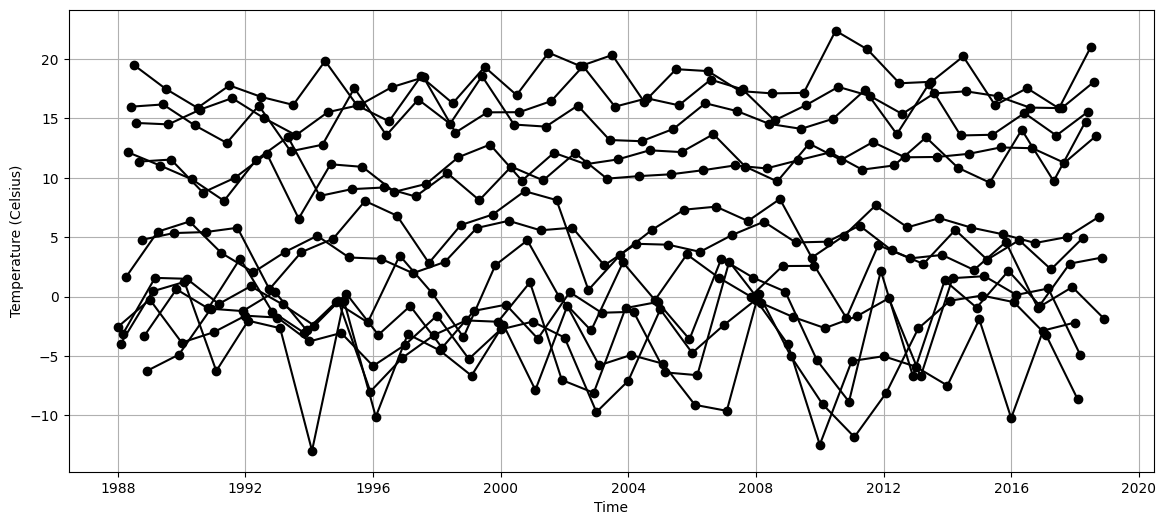

In [9]:
# Create the figure and subplot axes
fig, ax = plt.subplots(figsize=(14,6))

# Loop through months (Jan=1, Dec=12)
for month in range(1, 13):
    # Select data for the current month using datetime index
    data_month = selection[selection.index.month == month]
    # Plot temperature values for the current month
    ax.plot(
        data_month.index,
        data_month["TEMP_C"],
        "ko-")

#Set plot title and axis
ax.set_title
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (Celsius)")

#Add grid to the background
ax.grid(True)

# Set output file name
outputfp = "temp_line_plot.png"

# Save plot as image
plt.savefig(outputfp, dpi=300)
plt.show()

In [10]:
import os

# Check that output file exists (you can also open the file and check that the plot looks ok!)
os.path.exists(outputfp)

True

**Reminder**: Don't forget to upload your figure and the modified notebook into your personal GitHub repository!

### Done!

### An interactive plot (*optional*; 0 points)

Create an interactive version of the monthly temperatures plot using [hvPlot](https://hvplot.holoviz.org/)!

In [11]:
# Import pandas submodule of hvplot in this cell
!pip install hvplot
import hvplot.pandas

In [30]:
# Plot an interactive visualization of the monthly temperatures. 

# Load data
# File Path
fp = "data/helsinki-vantaa.csv"

#Read File
df = pd.read_csv(
    fp,
    sep=",",
    # Parse datetime
    parse_dates=["DATE"],
    # Set datetime index
    index_col="DATE",
)

# Sort by date (CRUCIAL)
df = df.sort_index()

# Create month column
df["month"] = df.index.month

In [31]:
# This test print should print first five rows
print(df.head())

               USAF     TEMP_F    TEMP_C  REF_TEMP_C    DIFF_C  month
DATE                                                                 
1952-01-01  29740.0  28.347826 -2.028986   -4.936650  2.907665      1
1952-02-01  29740.0  24.910714 -3.938492   -5.656795  1.718303      2
1952-03-01  29740.0  14.319328 -9.822596   -1.881240 -7.941355      3
1952-04-01  29740.0  39.364407  4.091337    3.927530  0.163807      4
1952-05-01  29740.0  44.932773  7.184874   10.421878 -3.237004      5


In [32]:
# Note! You might have to re-order the data before plotting.
# Apparently, hvplot works best when each line is a column


In [33]:
# This test print should print first five rows
print(monthly.head())

month             1         2         3         4         5   6   7   8   9   \
DATE                                                                           
1952-01-01 -2.028986       NaN       NaN       NaN       NaN NaN NaN NaN NaN   
1952-02-01       NaN -3.938492       NaN       NaN       NaN NaN NaN NaN NaN   
1952-03-01       NaN       NaN -9.822596       NaN       NaN NaN NaN NaN NaN   
1952-04-01       NaN       NaN       NaN  4.091337       NaN NaN NaN NaN NaN   
1952-05-01       NaN       NaN       NaN       NaN  7.184874 NaN NaN NaN NaN   

month       10  11  12  
DATE                    
1952-01-01 NaN NaN NaN  
1952-02-01 NaN NaN NaN  
1952-03-01 NaN NaN NaN  
1952-04-01 NaN NaN NaN  
1952-05-01 NaN NaN NaN  


In [34]:

# So we can see the names of each month in the legend
monthly.columns = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]


In [37]:
import hvplot.pandas

plot = None

for m in range(1, 13):
    data = df[df.index.month == m]["TEMP_C"]
    p = data.hvplot(
        label=data.index[0].strftime("%B"),
        line_width=2
    )
    plot = p if plot is None else plot * p

plot.opts(
    title="Helsinki-Vantaa Airport",
    xlabel="Time",
    ylabel="Temperature (Celsius)",
    height=500,
    width=900,
    legend_position="top_left"
)


:Overlay
   .Curve.January   :Curve   [DATE]   (TEMP_C)
   .Curve.February  :Curve   [DATE]   (TEMP_C)
   .Curve.March     :Curve   [DATE]   (TEMP_C)
   .Curve.April     :Curve   [DATE]   (TEMP_C)
   .Curve.May       :Curve   [DATE]   (TEMP_C)
   .Curve.June      :Curve   [DATE]   (TEMP_C)
   .Curve.July      :Curve   [DATE]   (TEMP_C)
   .Curve.August    :Curve   [DATE]   (TEMP_C)
   .Curve.September :Curve   [DATE]   (TEMP_C)
   .Curve.October   :Curve   [DATE]   (TEMP_C)
   .Curve.November  :Curve   [DATE]   (TEMP_C)
   .Curve.December  :Curve   [DATE]   (TEMP_C)

In [39]:
# Save fig
import holoviews as hv

hv.save(plot, "helsinki_vantaa_monthly_temperatures.html")
